In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt



from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import logging
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from sklearn.metrics import confusion_matrix

In [ ]:
from tensorflow.keras.applications.vgg19 import preprocess_input

train_datagen = image.ImageDataGenerator(
    preprocessing_function=preprocess_input,   # <-- VGG19's own preprocessing (was rescale=1./255)
    shear_range=0.2,                           # <-- matched to ResNet50 baseline (was 0.3)
    zoom_range=0.2,                            # <-- matched to ResNet50 baseline (was 0.3)
    horizontal_flip=True,
)
validation_datagen = image.ImageDataGenerator(
    preprocessing_function=preprocess_input
)


In [ ]:
train = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/Research/original_data_leveling/up_train',
    target_size = (224, 224),
    batch_size = 32,
    class_mode = 'categorical'
)

validation = validation_datagen.flow_from_directory(
    '/content/drive/MyDrive/Research/original_data_leveling/up_val',
    target_size = (224, 224),
    batch_size = 32,
    class_mode = 'categorical'
)

test = validation_datagen.flow_from_directory(
    '/content/drive/MyDrive/Research/original_data_leveling/up_test',
    target_size = (224, 224),
    batch_size = 32,
    shuffle = False,
    class_mode = 'categorical'
)

Found 10500 images belonging to 3 classes.
Found 1500 images belonging to 3 classes.
Found 3000 images belonging to 3 classes.


In [ ]:
VGG19 = tf.keras.applications.VGG19(
    include_top=False,
    weights = 'imagenet',
    input_shape=(224,224,3),
    )

In [ ]:
VGG19.trainable = False

In [ ]:
model = tf.keras.models.Sequential([
  VGG19,
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dropout(0.8),
  tf.keras.layers.Dense(units=1024, activation='relu'),
  tf.keras.layers.Dense(units=512, activation='relu'),
  tf.keras.layers.Dense(units=3, activation='softmax'),
])

In [ ]:
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    25,691,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,241,859 (176.40 MB)

 Trainable params: 26,217,475 (100.01 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [ ]:
history = model.fit(
    x = train,
    validation_data = validation,
    epochs = 10
)

Epoch 1/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 856s 3s/step - accuracy: 0.8530 - loss: 1.8548 - val_accuracy: 0.9120 - val_loss: 0.2547
Epoch 2/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 153s 463ms/step - accuracy: 0.8997 - loss: 0.3026 - val_accuracy: 0.9407 - val_loss: 0.1378
Epoch 3/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 153s 465ms/step - accuracy: 0.9179 - loss: 0.2242 - val_accuracy: 0.9573 - val_loss: 0.1065
Epoch 4/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 152s 462ms/step - accuracy: 0.9273 - loss: 0.1918 - val_accuracy: 0.9540 - val_loss: 0.1077
Epoch 5/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 153s 465ms/step - accuracy: 0.9307 - loss: 0.1775 - val_accuracy: 0.9653 - val_loss: 0.0915
Epoch 6/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 158s 479ms/step - accuracy: 0.9343 - loss: 0.1664 - val_accuracy: 0.9647 - val_loss: 0.0868
Epoch 7/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 157s 477ms/step - accuracy: 0.9414 - loss: 0.1511 - val_accuracy: 0.9460 - val_loss: 0.1243
Epoch 8/10
329/329 ━━━━━━━━━━━━━━━━━━━━ 157s 477ms/step - accuracy: 0.9462 - lo

In [ ]:
# Evaluate the loss and accuracy
loss, accuracy = model.evaluate(test)

# Print the accuracy
print("Accuracy: " + str(accuracy))
# Print the loss
print("Loss: " + str(loss))

94/94 ━━━━━━━━━━━━━━━━━━━━ 1005s 11s/step - accuracy: 0.9733 - loss: 0.0697
Accuracy: 0.9733333587646484
Loss: 0.06973142176866531


In [ ]:
test.class_indices

{'Lung_Adenocarcinoma': 0,
 'Lung_Benign_Tissue': 1,
 'Lung_Squamos_Cell_Carcinoma': 2}

In [ ]:
import numpy as np
from sklearn import metrics

predictions = model.predict(test)
predicted_classes = np.argmax(predictions, axis = 1)
true_classes = test.classes
class_labels = ['Lung_Adenocarcinoma', 'Lung_Benign_Tissue', 'Lung_Squamous_Cell_Carcinoma']
report = metrics.classification_report(true_classes, predicted_classes, target_names = class_labels)
print(report)

94/94 ━━━━━━━━━━━━━━━━━━━━ 20s 208ms/step
                              precision    recall  f1-score   support

         Lung_Adenocarcinoma       0.96      0.96      0.96      1000
          Lung_Benign_Tissue       1.00      1.00      1.00      1000
Lung_Squamous_Cell_Carcinoma       0.96      0.95      0.96      1000

                    accuracy                           0.97      3000
                   macro avg       0.97      0.97      0.97      3000
                weighted avg       0.97      0.97      0.97      3000



<Axes: >

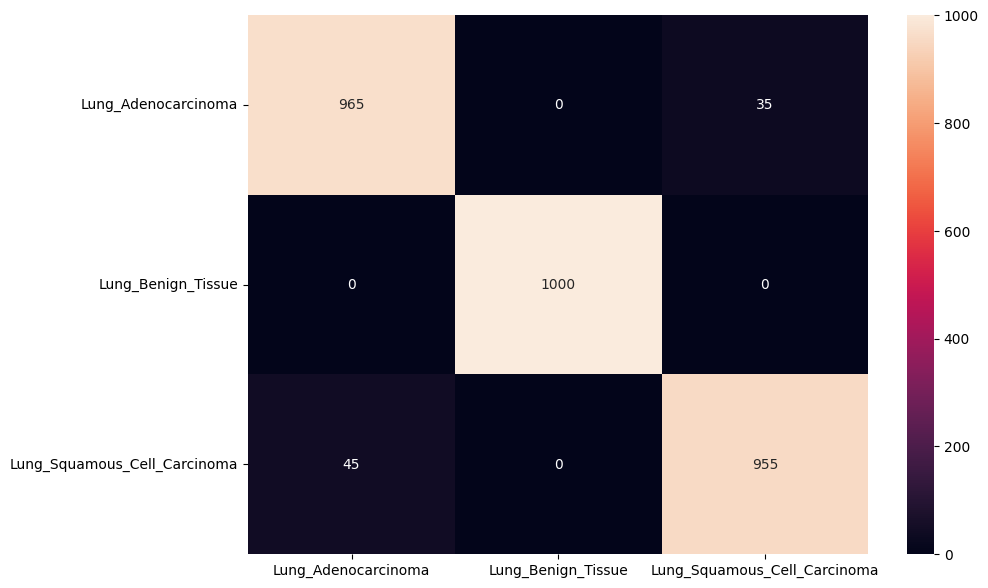

In [ ]:
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt

# Label order MUST match test.class_indices: Adenocarcinoma=0, Benign=1, Squamous=2
labels = ['Lung_Adenocarcinoma', 'Lung_Benign_Tissue', 'Lung_Squamous_Cell_Carcinoma']
cm = metrics.confusion_matrix(true_classes, predicted_classes)
df_cm = pd.DataFrame(cm, index=labels, columns=labels)
plt.figure(figsize = (10,7))
sn.heatmap(df_cm, annot=True, fmt='d')


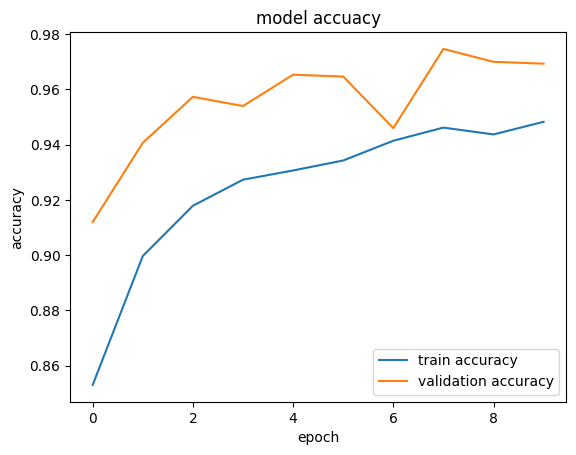

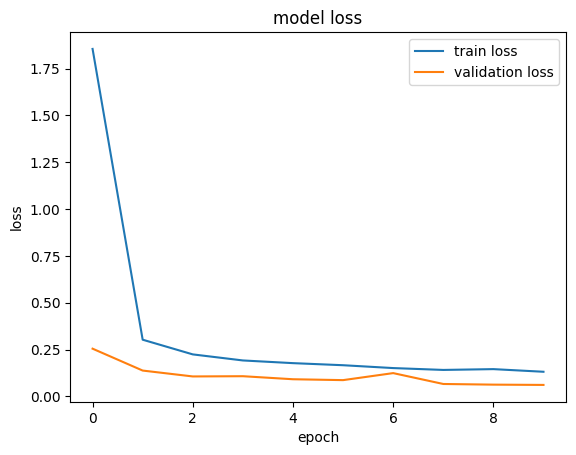

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("model accuacy")
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train accuracy', 'validation accuracy'], loc='lower right')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train loss', 'validation loss'], loc='upper right')
plt.show()